# MAE Latent Stability — Fixed patch vs 25% random sampling

According to the paper, the encoder only sees 25% of the image. To analyze its behavior in the latent space, we fix a patch and draw different masks representing the 25% of visible patches. This allows us to analyze whether the latent representation varies across inferences.

Interpretations:
- High cosine between draws: the patch representation is not sensitive to the visible context — information is more localized.
- Low cosine / high dispersion: the token strongly depends on its visible neighbors — information is distributed across the visible subset.

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torchvision import transforms
from torchvision.datasets import ImageFolder
from transformers import ViTImageProcessor, ViTMAEModel

sys.path.insert(0, str(Path('.').resolve() / 'src'))
from mae_patch_stability import (
    BORDER_PATCH_IDS,
    GRID,
    PATCH_BORDERS,
    PATCH_CENTER,
    PATCH_CORNERS,
    PATCH_PROBES,
    build_border_noise,
    build_noise,
    collect_representation_bank,
    convergence_vs_K,
    encode_once,
    latent_for_patch,
    mean_offdiag_cos,
    patch_rc,
    patch_region,
    pca_coords,
    sample_stability,
    _cosine_matrix,
    StabilityResult,
    save_umap_bundle,
    stability_across_images,
    stability_grid,
    summarize,
)

try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False


OUTPUT_DIR = Path('outputs/patch_stability')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

#réduire N et K et Full_Grid False pour tests avant de brûler le pc
N_IMAGES = 30          # nb images
K_BATCH = 24           # masques par (image, patch)
K_GRID = 12            # masques par cellule pour une carte 14x14
K_UMAP = 6             # masques par image pour banque UMAP
RUN_FULL_GRID = True   # carte complète 14x14 (une image, ~196*K_GRID forwards)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
import os
MODEL_PATH = './vit-mae-large' if os.path.exists('./vit-mae-large') else 'facebook/vit-mae-large'

# Auto-download ImageNette if not found locally
_inet_path = None
for _candidate in ['./imagenette/val', './imagenette2-320/val', './imagenette2/val']:
    if os.path.exists(_candidate):
        _inet_path = _candidate
        break
if _inet_path is None:
    import urllib.request, tarfile
    print('Downloading ImageNette (~1.5 GB)...')
    urllib.request.urlretrieve(
        'https://s3.amazonaws.com/fast-ai-imageclas/imagenette2-320.tgz',
        'imagenette2-320.tgz')
    with tarfile.open('imagenette2-320.tgz') as _tar:
        _tar.extractall('.')
    os.remove('imagenette2-320.tgz')
    _inet_path = './imagenette2-320/val'
    print('Done.')

K = 64          # nombre de masques tirés
SEED0 = 0
FIXED_PATCH_ID = 98   # centre approx. (7, 7) sur grille 14x14

processor = ViTImageProcessor(
    size={'height': 224, 'width': 224},
    image_mean=[0.485, 0.456, 0.406],
    image_std=[0.229, 0.224, 0.225],
)
encoder = ViTMAEModel.from_pretrained(MODEL_PATH).to(DEVICE)
encoder.eval()
print('Device:', DEVICE)

mkdir -p failed for path /home/ann/.config/matplotlib: [Errno 13] Permission denied: '/home/ann/.config/matplotlib'
Matplotlib created a temporary cache directory at /tmp/matplotlib-hgg1svr4 because there was an issue with the default path (/home/ann/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
/home/ann/.venvs/computer-vision-mae/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu


Classe: n01440764


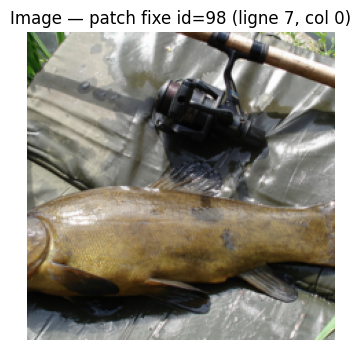

In [2]:
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
])
dataset_val = ImageFolder(root=_inet_path, transform=transform)
image_pil, label = dataset_val[0]
print('Classe:', dataset_val.classes[label])

plt.figure(figsize=(4, 4))
plt.imshow(image_pil)
r, c = patch_rc(FIXED_PATCH_ID)
plt.title(f'Image — patch fixe id={FIXED_PATCH_ID} (ligne {r}, col {c})')
plt.axis('off')
plt.show()

## 1. Fixed patch always visible (25% visible including our patch)

In [ ]:
res_fixed = sample_stability(
    image_pil, encoder, processor, DEVICE,
    patch_id=FIXED_PATCH_ID, K=K, seed0=SEED0, fixed=True,
)
stats_fixed = summarize(res_fixed)
for k, v in stats_fixed.items():
    print(f'{k:24s}: {v:.4f}' if isinstance(v, float) else f'{k:24s}: {v}')

patch_id                : 98
fixed                   : 1.0000
K                       : 64.0000
mean_cos_patch          : 0.9327
std_cos_patch           : 0.0380
mean_cos_cls            : 0.9899
mean_cos_mean           : 0.8899
mean_l2_norm_patch      : 14.2313
mean_std_per_dim_patch  : 0.1046
mean_pairwise_l2_patch  : 5.1003


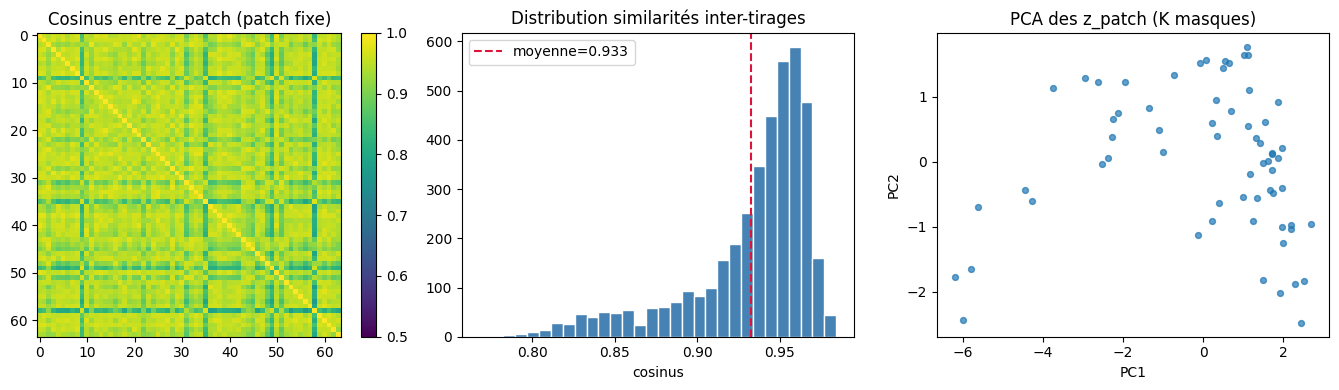

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

im = axes[0].imshow(res_fixed.pairwise_cos_patch, vmin=0.5, vmax=1.0, cmap='viridis')
axes[0].set_title('Cosinus entre z_patch (patch fixe)')
plt.colorbar(im, ax=axes[0], fraction=0.046)

k_eff = res_fixed.z_patch.shape[0]
off = res_fixed.pairwise_cos_patch[~np.eye(k_eff, dtype=bool)]
axes[1].hist(off, bins=30, color='steelblue', edgecolor='white')
axes[1].axvline(off.mean(), color='crimson', ls='--', label=f'moyenne={off.mean():.3f}')
axes[1].set_xlabel('cosinus')
axes[1].set_title('Distribution similarités inter-tirages')
axes[1].legend()

xy = pca_coords(res_fixed.z_patch)
axes[2].scatter(xy[:, 0], xy[:, 1], s=18, alpha=0.7)
axes[2].set_title('PCA des z_patch (K masques)')
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')

plt.tight_layout()
plt.show()

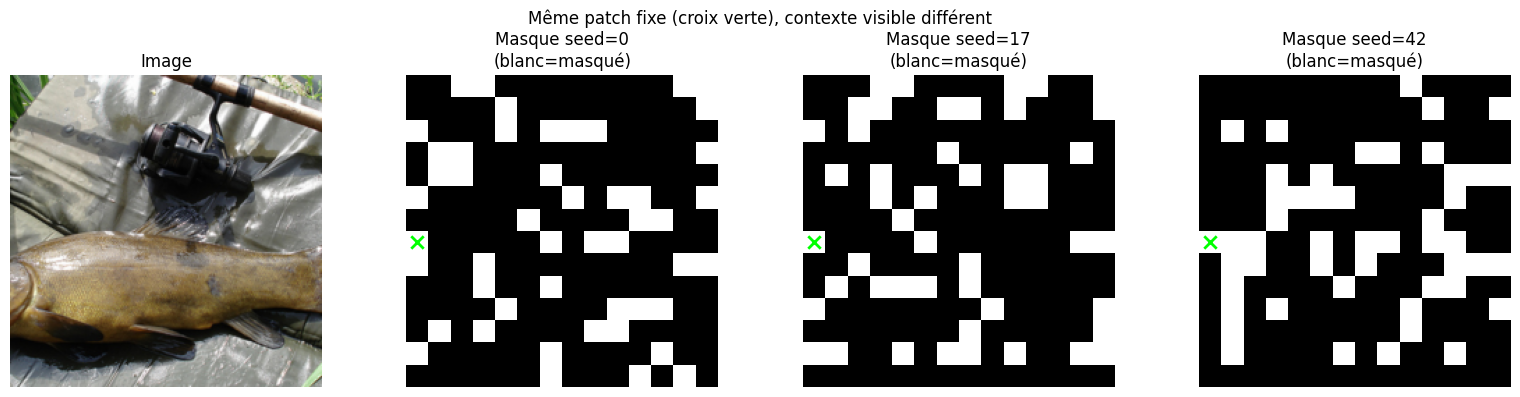

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(image_pil)
axes[0].set_title('Image')
axes[0].axis('off')

for ax, k in zip(axes[1:], [0, 17, 42]):
    m = res_fixed.masks[k].numpy().reshape(GRID, GRID)
    ax.imshow(m, cmap='gray_r', vmin=0, vmax=1)
    r, c = patch_rc(FIXED_PATCH_ID)
    ax.scatter([c], [r], c='lime', s=80, marker='x', linewidths=2)
    ax.set_title(f'Masque seed={SEED0 + k}')
    ax.axis('off')

plt.suptitle('Même patch fixe (croix verte), contexte visible différent')
plt.tight_layout()
plt.show()

## 2. Same patch **without** forcing it visible (100% random mask)

We only keep draws where the patch falls within the 25% (approximately 25% of seeds). Comparison: forced visibility vs random.

In [ ]:
res_free = sample_stability(
    image_pil, encoder, processor, DEVICE,
    patch_id=FIXED_PATCH_ID, K=K, seed0=SEED0, fixed=False,
)
stats_free = summarize(res_free)
print('patch fixé visible')
print(f"mean cos z_patch: {stats_fixed['mean_cos_patch']:.4f}")
print('patch seulement si tiré dans les 25%')
print(f"K effectif: {int(stats_free['K'])}")
print(f"mean cos z_patch: {stats_free['mean_cos_patch']:.4f}")

--- patch fixé visible ---
mean cos z_patch: 0.9327
--- patch seulement si tiré dans les 25% ---
K effectif: 64
mean cos z_patch: 0.9229


## 3. Stability map by fixed patch position

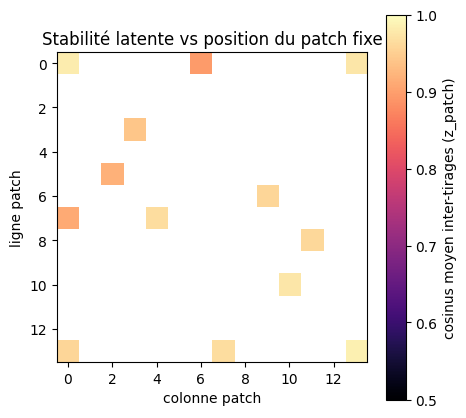

In [ ]:
probe_ids = [
    0, 13, 182, 195,          # coins
    6, 189, 93, 102,          # bords
    98,                       # centre
    45, 150, 72, 123,         # intérieur
]
stability_map = np.full((GRID, GRID), np.nan)
for pid in probe_ids:
    r = sample_stability(
        image_pil, encoder, processor, DEVICE,
        patch_id=pid, K=32, seed0=100, fixed=True,
    )
    rr, cc = patch_rc(pid)
    stability_map[rr, cc] = r.mean_offdiag_cos_patch

plt.figure(figsize=(5, 5))
plt.imshow(stability_map, cmap='magma', vmin=0.5, vmax=1.0)
plt.colorbar(label='cosinus moyen inter-tirages (z_patch)')
plt.title('Latent stability vs. position with patch fixed')
plt.xlabel('colonne patch')
plt.ylabel('ligne patch')
plt.show()

## 4. Three levels of representation

| Vector | Role |
|--------|------|
| `z_patch` | Fixed patch token after attention over the visible subset |
| `z_mean` | Mean of the 49 visible tokens (excluding CLS) |
| `z_cls` | Global CLS token |

In general `z_cls` and `z_mean` vary **more** than `z_patch` at the same location, as they aggregate the entire visible context which changes at each draw.

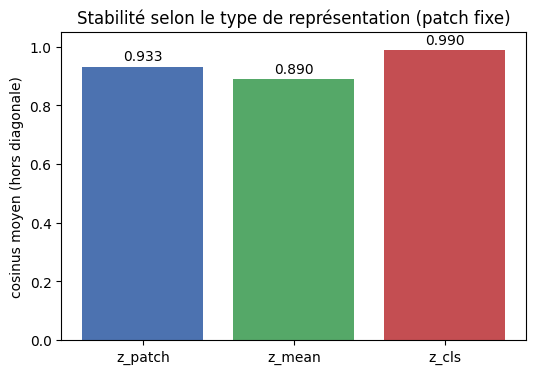

In [ ]:
labels = ['z_patch', 'z_mean', 'z_cls']
sims = [
    res_fixed.pairwise_cos_patch,
    res_fixed.pairwise_cos_mean,
    res_fixed.pairwise_cos_cls,
]
means = [mean_offdiag_cos(s) for s in sims]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(labels, means, color=['#4c72b0', '#55a868', '#c44e52'])
ax.set_ylim(0, 1.05)
ax.set_ylabel('mean cosine (except diagonale)')
ax.set_title('Stability basedon the representation type (patch fixed)')
for i, m in enumerate(means):
    ax.text(i, m + 0.02, f'{m:.3f}', ha='center')
plt.show()

## 5. Full 14×14 map (one image)

Stability for **each** fixed patch position. Expensive: `196 × K_GRID` forward passes.

In [ ]:
if RUN_FULL_GRID:
    patch_map, cls_map = stability_grid(
        image_pil, encoder, processor, DEVICE,
        K=K_GRID, seed0=500,
    )
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
    for ax, data, title in zip(
        axes,
        [patch_map, cls_map],
        ['z_patch (patch fixé)', 'z_cls'],
    ):
        im = ax.imshow(data, cmap='magma', vmin=0.4, vmax=1.0)
        ax.set_title(f'Stabilité — {title}')
        plt.colorbar(im, ax=ax, fraction=0.046)
    plt.suptitle('Mean inter-mask cosine based on fixed patch position')
    plt.tight_layout()
    plt.show()

    print('Centre z_patch:', float(patch_map[7, 7]))
    print('Coin HG z_patch:', float(patch_map[0, 0]))
    print('Moyenne globale:', float(np.nanmean(patch_map)))

KeyboardInterrupt: 

## 5b. Visible context restricted to the border

Same plot as section 5, but the 49 visible patches are drawn from the 52 border positions (3 border patches are masked at each draw; the interior always remains masked). Only border cells have a measured stability.

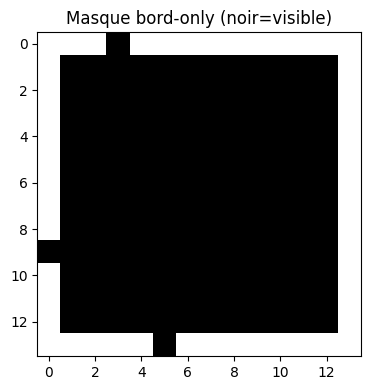

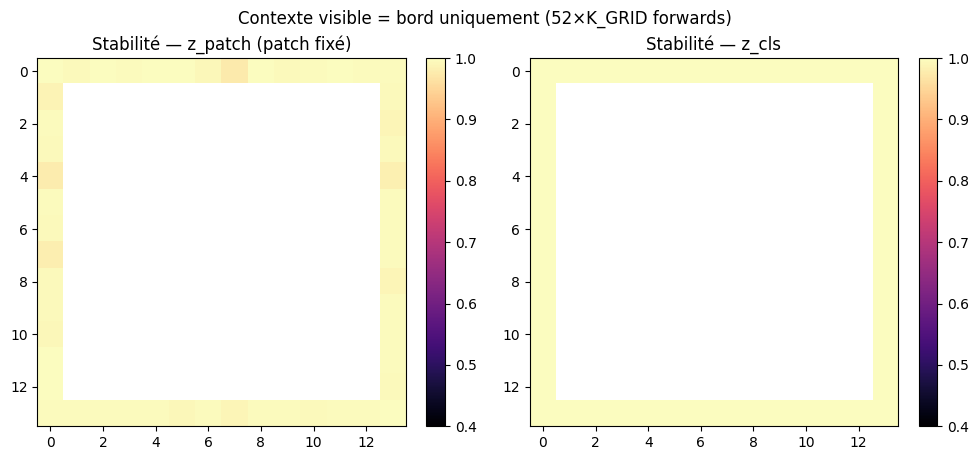

Bord (ex. patch 6) z_patch: 0.9915930032730103
Centre (NaN attendu): nan
Moyenne bord: 0.9942271709442139


In [ ]:
if RUN_FULL_GRID:
    # Aperçu d'un masque bord-only
    noise_demo = build_border_noise(PATCH_BORDERS[0], seed=42, device=DEVICE)
    _, mask_demo, _, _ = encode_once(image_pil, encoder, processor, DEVICE, noise=noise_demo)
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(mask_demo.cpu().numpy().reshape(GRID, GRID), cmap='gray_r', vmin=0, vmax=1)
    ax.set_title('Mask bord-only (noir=visible)')
    plt.tight_layout()
    plt.show()

    patch_map_border, cls_map_border = stability_grid(
        image_pil, encoder, processor, DEVICE,
        K=K_GRID, seed0=600,
        visible_region='border',
    )
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
    for ax, data, title in zip(
        axes,
        [patch_map_border, cls_map_border],
        ['z_patch (patch fixé)', 'z_cls'],
    ):
        im = ax.imshow(data, cmap='magma', vmin=0.4, vmax=1.0)
        ax.set_title(f'Stabilité — {title}')
        plt.colorbar(im, ax=ax, fraction=0.046)
    plt.suptitle('Contexte visible = bord uniquement (52×K_GRID forwards)')
    plt.tight_layout()
    plt.show()

    print('Bord (ex. patch 6) z_patch:', float(patch_map_border[0, 6]))
    print('Centre (NaN attendu):', patch_map_border[7, 7])
    print('Moyenne bord:', float(np.nanmean(patch_map_border)))

## 5c. Visible context: border + 3 central patches

The 3 most central patches are always kept visible and the 49 visible patches are completed with border patches.
This forces the encoder to rely on very little useful information from the image.

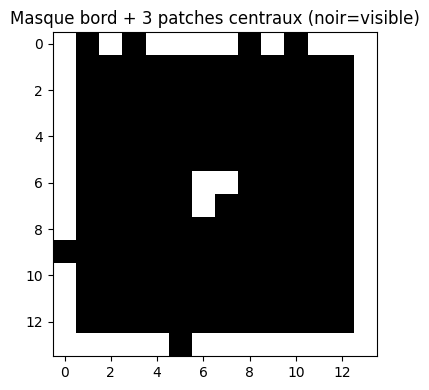

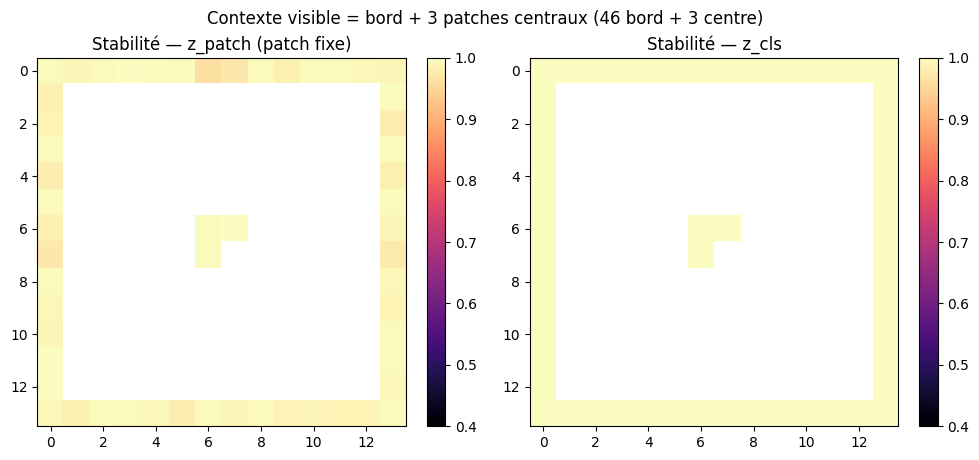

Centre 3 patches visibles: [90, 91, 104]
Moyenne bord+centre3: 0.9900468587875366


In [ ]:
if RUN_FULL_GRID:
    # 3 patches centraux fixes + 46 patches tirés uniquement parmi le bord
    NUM_PATCHES = GRID * GRID
    center_distances = [
        ((patch_rc(pid)[0] - (GRID - 1) / 2) ** 2 + (patch_rc(pid)[1] - (GRID - 1) / 2) ** 2, pid)
        for pid in range(NUM_PATCHES)
    ]
    CENTER3_PATCH_IDS = [pid for _, pid in sorted(center_distances)[:3]]
    from mae_patch_stability import _cosine_matrix

    def build_border_center3_noise(center_ids, seed, device, *, n_patches=NUM_PATCHES):
        gen = torch.Generator(device=device)
        gen.manual_seed(seed)
        noise = torch.full((1, n_patches), float('inf'), device=device)
        border_noise = torch.rand(1, len(BORDER_PATCH_IDS), generator=gen, device=device)
        for j, pid in enumerate(BORDER_PATCH_IDS):
            noise[0, pid] = border_noise[0, j]
        for pid in center_ids:
            noise[0, pid] = -1.0
        return noise

    def sample_stability_custom_noise(image, encoder, processor, device, patch_id, *, K=16, seed0=0, fixed=True):
        z_patch, z_cls, z_mean, masks = [], [], [], []
        seed = seed0
        attempts = 0
        max_attempts = K * 30
        while len(z_patch) < K and attempts < max_attempts:
            noise = build_border_center3_noise(CENTER3_PATCH_IDS, seed, device)
            hidden, mask, _, ids_keep = encode_once(image, encoder, processor, device, noise=noise)
            seed += 1
            attempts += 1
            if fixed and mask[patch_id] != 0:
                continue
            z_patch.append(latent_for_patch(hidden, ids_keep, patch_id))
            z_cls.append(hidden[0, 0])
            z_mean.append(hidden[0, 1:].mean(dim=0))
            masks.append(mask.cpu())
        if len(z_patch) < 2:
            raise RuntimeError("Not enough successful samples for custom mask.")
        zp = torch.stack(z_patch)
        zc = torch.stack(z_cls)
        zm = torch.stack(z_mean)
        return StabilityResult(
            patch_id=patch_id,
            fixed=fixed,
            z_patch=zp,
            z_cls=zc,
            z_mean=zm,
            masks=torch.stack(masks),
            pairwise_cos_patch=_cosine_matrix(zp),
            pairwise_cos_cls=_cosine_matrix(zc),
            pairwise_cos_mean=_cosine_matrix(zm),
        )

    def stability_grid_border_center3(image, encoder, processor, device, *, K=12, seed0=0):
        patch_map = np.full((GRID, GRID), np.nan, dtype=np.float32)
        cls_map = np.full((GRID, GRID), np.nan, dtype=np.float32)
        visible_ids = set(BORDER_PATCH_IDS) | set(CENTER3_PATCH_IDS)
        for pid in sorted(visible_ids):
            res = sample_stability_custom_noise(
                image, encoder, processor, device,
                patch_id=pid, K=K, seed0=seed0 + pid, fixed=True,
            )
            rr, cc = patch_rc(pid)
            patch_map[rr, cc] = res.mean_offdiag_cos_patch
            cls_map[rr, cc] = mean_offdiag_cos(res.pairwise_cos_cls)
        return patch_map, cls_map

    noise_demo = build_border_center3_noise(CENTER3_PATCH_IDS, seed=42, device=DEVICE)
    _, mask_demo, _, _ = encode_once(image_pil, encoder, processor, DEVICE, noise=noise_demo)
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(mask_demo.cpu().numpy().reshape(GRID, GRID), cmap='gray_r', vmin=0, vmax=1)
    ax.set_title('Masque bord + 3 patches centraux (noir=visible)')
    plt.tight_layout()
    plt.show()

    patch_map_center3, cls_map_center3 = stability_grid_border_center3(
        image_pil, encoder, processor, DEVICE,
        K=K_GRID, seed0=800,
    )
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
    for ax, data, title in zip(
        axes,
        [patch_map_center3, cls_map_center3],
        ['z_patch (patch fixe)', 'z_cls'],
    ):
        im = ax.imshow(data, cmap='magma', vmin=0.4, vmax=1.0)
        ax.set_title(f'Stabilité — {title}')
        plt.colorbar(im, ax=ax, fraction=0.046)
    plt.suptitle('Contexte visible = bord + 3 patches centraux (46 bord + 3 centre)')
    plt.tight_layout()
    plt.show()

    print('Centre 3 patches visibles:', CENTER3_PATCH_IDS)
    print('Moyenne bord+centre3:', float(np.nanmean(patch_map_center3)))


## 6. Multiple images — center vs border vs corner

We draw `N_IMAGES` images from the val set and compare the stability of the **same masking mechanism** depending on the region of the fixed patch.

In [ ]:
rng = np.random.default_rng(42)
all_idx = np.arange(len(dataset_val))
image_indices = [int(i) for i in sorted(rng.choice(all_idx, size=min(N_IMAGES, len(all_idx)), replace=False))]

rows = stability_across_images(
    dataset_val, encoder, processor, DEVICE,
    image_indices,
    patch_ids=PATCH_PROBES,
    K=K_BATCH,
    class_names=dataset_val.classes,
)
print(f'{len(rows)} mesures ({len(image_indices)} images × {len(PATCH_PROBES)} patches)')

import csv
csv_path = OUTPUT_DIR / 'stability_by_image_patch.csv'
with open(csv_path, 'w', newline='', encoding='utf-8') as f:
    w = csv.DictWriter(f, fieldnames=rows[0].keys())
    w.writeheader()
    w.writerows(rows)
print('Export:', csv_path)

KeyboardInterrupt: 

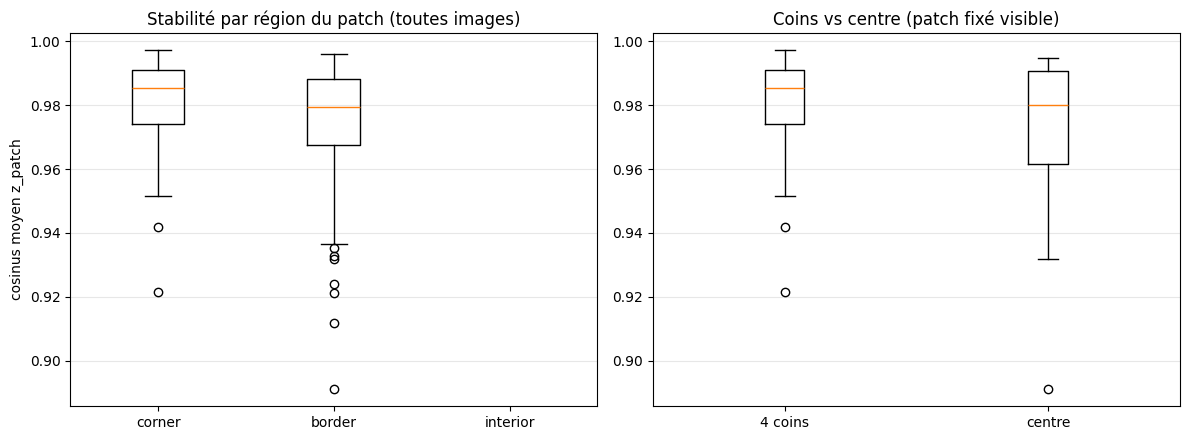

corner    n=120  mean=0.9812  std=0.0130
border    n=150  mean=0.9747  std=0.0189
interior  n=  0  mean=nan  std=nan


/home/ann/.venvs/computer-vision-mae/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/ann/.venvs/computer-vision-mae/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/ann/.venvs/computer-vision-mae/lib/python3.12/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/ann/.venvs/computer-vision-mae/lib/python3.12/site-packages/numpy/_core/_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/ann/.venvs/computer-vision-mae/lib/python3.12/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [ ]:
regions = ['corner', 'border', 'interior']
by_region = {r: [x['mean_cos_patch'] for x in rows if x['region'] == r] for r in regions}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
data = [by_region[r] for r in regions]
axes[0].boxplot(data, tick_labels=regions)
axes[0].set_ylabel('cosinus moyen z_patch')
axes[0].set_title('Stabilité par région du patch (toutes images)')
axes[0].grid(axis='y', alpha=0.3)

centers = [x['mean_cos_patch'] for x in rows if x['patch_id'] == PATCH_CENTER]
corners = [x['mean_cos_patch'] for x in rows if x['patch_id'] in PATCH_CORNERS]
axes[1].boxplot([corners, centers], tick_labels=['4 coins', 'centre'])
axes[1].set_title('Coins vs centre (patch fixé visible)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

for r in regions:
    v = by_region[r]
    print(f"{r:8s}  n={len(v):3d}  mean={np.mean(v):.4f}  std={np.std(v):.4f}")

## Part 5D
Added later because it required definitions from section 6.
We further demonstrate that the spatial localization of chosen patches influences the image representation in the latent space.

## 7. One image per class (10 ImageNette classes)

Fixed central patch — does stability change depending on the semantics of the object?

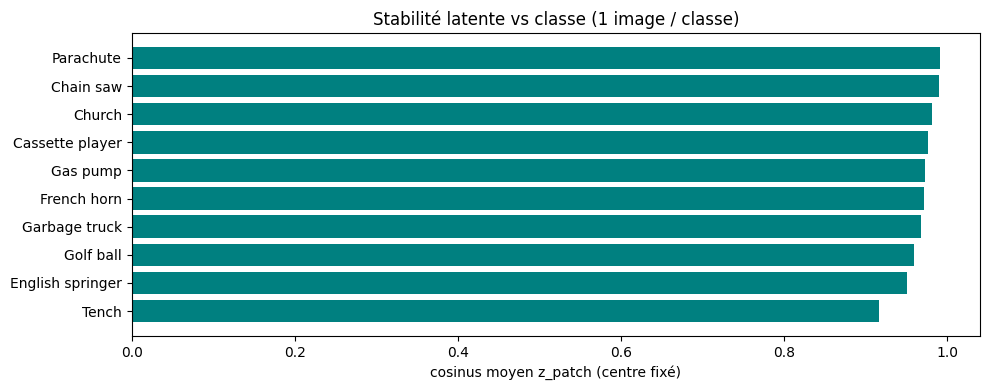

In [ ]:
# Mapping des codes ImageNette vers noms descriptifs
imagenette_mapping = {
    'n01440764': 'Tench',
    'n02102040': 'English springer',
    'n02979186': 'Cassette player',
    'n03000684': 'Chain saw',
    'n03028079': 'Church',
    'n03394916': 'French horn',
    'n03417042': 'Garbage truck',
    'n03425413': 'Gas pump',
    'n03445777': 'Golf ball',
    'n03888257': 'Parachute',
}

per_class_idx = []
for c in range(len(dataset_val.classes)):
    idx = next(i for i in range(len(dataset_val)) if dataset_val[i][1] == c)
    per_class_idx.append(idx)

rows_cls = stability_across_images(
    dataset_val, encoder, processor, DEVICE,
    per_class_idx,
    patch_ids=(PATCH_CENTER,),
    K=K_BATCH,
    class_names=dataset_val.classes,
)

names = [imagenette_mapping.get(r['class_name'], r['class_name']) for r in rows_cls]
vals = [r['mean_cos_patch'] for r in rows_cls]
order = np.argsort(vals)

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh([names[i] for i in order], [vals[i] for i in order], color='teal')
ax.set_xlabel('cosinus moyen z_patch (centre fixé)')
ax.set_title('Stabilité latente vs classe (1 image / classe)')
plt.tight_layout()
plt.show()

## 8. UMAP — representation cloud (multi-image, multi-mask)

Each point = one masked inference. Colors: class, image, or representation type (`patch` / `mean` / `cls`).

Embeddings: (270, 1024) → outputs/patch_stability/latent_bank_center_patch.npz


/home/ann/.venvs/computer-vision-mae/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


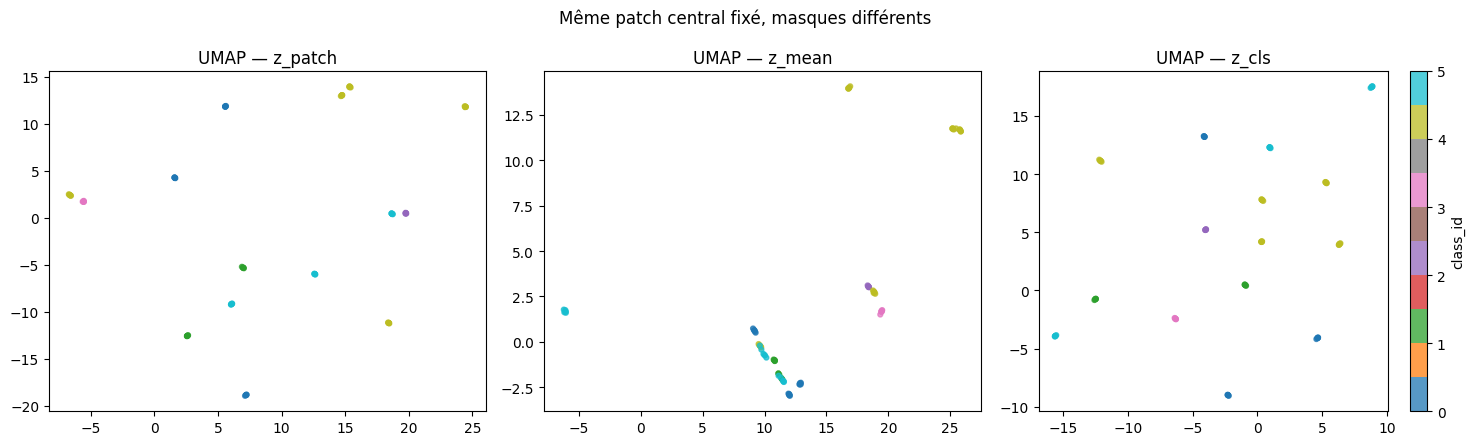

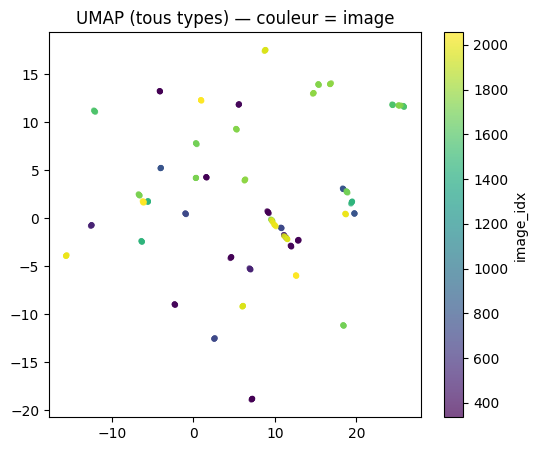

In [ ]:
umap_indices = image_indices[:min(15, len(image_indices))]
emb, meta = collect_representation_bank(
    dataset_val, encoder, processor, DEVICE,
    umap_indices,
    patch_id=PATCH_CENTER,
    K=K_UMAP,
    rep_types=('patch', 'mean', 'cls'),
)
npz_path = OUTPUT_DIR / 'latent_bank_center_patch.npz'
save_umap_bundle(str(npz_path), emb, meta)
print('Embeddings:', emb.shape, '→', npz_path)

if not HAS_UMAP:
    print('pip install umap-learn pour la projection 2D')
else:
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
    xy = reducer.fit_transform(emb)

    rep_names = ['patch', 'mean', 'cls']
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    for ax, code, title in zip(axes, [0, 1, 2], rep_names):
        m = meta['rep_type'] == code
        sc = ax.scatter(xy[m, 0], xy[m, 1], c=meta['class_id'][m], cmap='tab10', s=12, alpha=0.75)
        ax.set_title(f'UMAP — z_{title}')
    plt.colorbar(sc, ax=axes[-1], label='class_id')
    plt.suptitle('Même patch central fixé, masques différents')
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(6, 5))
    sc = ax.scatter(xy[:, 0], xy[:, 1], c=meta['image_idx'], cmap='viridis', s=10, alpha=0.7)
    plt.colorbar(sc, ax=ax, label='image_idx')
    ax.set_title('UMAP (tous types) — couleur = image')
    plt.show()

## 9. Convergence: mean over K masks

We measure how the **mean** of `z_patch` over a subset of draws becomes stable as K increases (bootstrap).

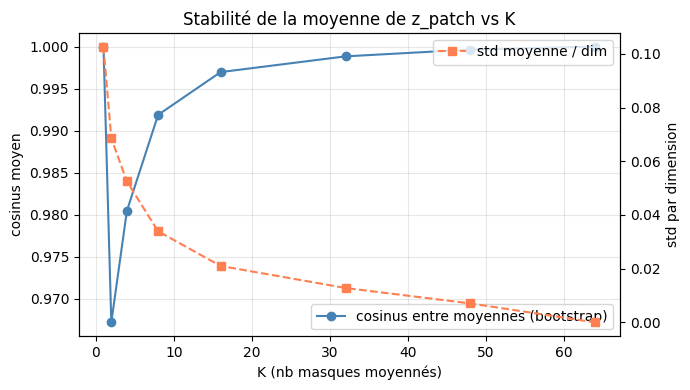

Interprétation : cosinus qui monte avec K → la moyenne sur masques réduit la variance (descripteur plus informatif/stable).


In [ ]:
K_list, cos_boot, std_boot = convergence_vs_K(
    image_pil, encoder, processor, DEVICE,
    patch_id=FIXED_PATCH_ID, K_values=(1, 2, 4, 8, 16, 32, 48, 64),
)

fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(K_list, cos_boot, 'o-', color='steelblue', label='cosinus entre moyennes (bootstrap)')
ax1.set_xlabel('K (nb masques moyennés)')
ax1.set_ylabel('cosinus moyen')
ax1.set_title('Stabilité de la moyenne de z_patch vs K')
ax1.grid(alpha=0.3)
ax2 = ax1.twinx()
ax2.plot(K_list, std_boot, 's--', color='coral', label='std moyenne / dim')
ax2.set_ylabel('std par dimension')
ax1.legend(loc='lower right')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()

print('Interprétation : cosinus qui monte avec K → la moyenne sur masques réduit la variance (descripteur plus informatif/stable).')

## 10. Distance to center vs stability (full grid)

If the 14×14 map was computed in section 5: correlation between distance to center and patch stability.

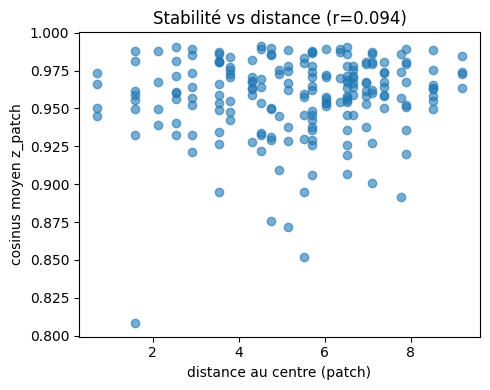

In [ ]:
if RUN_FULL_GRID:
    rr, cc = np.meshgrid(np.arange(GRID), np.arange(GRID), indexing='ij')
    dist = np.sqrt((rr - 6.5) ** 2 + (cc - 6.5) ** 2).ravel()
    stab = patch_map.ravel()
    ok = ~np.isnan(stab)
    corr = np.corrcoef(dist[ok], stab[ok])[0, 1]

    fig, ax = plt.subplots(figsize=(5, 4))
    ax.scatter(dist[ok], stab[ok], alpha=0.6)
    ax.set_xlabel('distance au centre (patch)')
    ax.set_ylabel('cosinus moyen z_patch')
    ax.set_title(f'Stabilité vs distance (r={corr:.3f})')
    plt.tight_layout()
    plt.show()

## 11. Discussion (link with MAE)

1. **Asymmetric masking**: at each forward pass, the encoder solves an *implicit regression* on only 49 patches. Attention weights mix information from co-visible patches → the fixed patch token is a function of the **random context**.

2. **Inter-draw variance**: if the PCA dispersion / mean cosine is low, a single masked inference is not sufficient to characterize the image: averaging is necessary to approximate a sufficient statistic.

3. **Position**: central vs corner patches may show different stabilities (structural neighborhood, object size in ImageNette).

4. **Information**: high variability = the encoder does not have access to the full image; the information about patch content is **partially redundant** with that of other visible patches, hence the sensitivity to the draw.

> Run `python scripts/download_mae.py` first if `pytorch_model.bin` is ~135 bytes (LFS pointer).